# Gráficas y pruebas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pipeline_rewritten import *
from pipeline_rewritten import _cp_tail_correlation_score

In [2]:
base_dir = Path.cwd().resolve()
repo_root = None
for candidate in [base_dir, *base_dir.parents]:
    if (candidate / "data").exists() and (candidate / "Hugo" / "Modulator.yaml").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise FileNotFoundError("No se pudo localizar la raíz del repositorio a partir del directorio actual")

yaml_path = repo_root / "Hugo" / "Modulator.yaml"

tx_path = repo_root / "data" / "vacio" / "iq_tx.bin"
rx_path = repo_root / "data" / "vacio" / "iq_rx.bin"

print(f"Raíz detectada: {repo_root}")
print(f"YAML: {yaml_path}")
print(f"TX: {tx_path}")
print(f"RX: {rx_path}")

Raíz detectada: /home/hugo/Escritorio/ISAC/Codigo-ISAC
YAML: /home/hugo/Escritorio/ISAC/Codigo-ISAC/Hugo/Modulator.yaml
TX: /home/hugo/Escritorio/ISAC/Codigo-ISAC/data/vacio/iq_tx.bin
RX: /home/hugo/Escritorio/ISAC/Codigo-ISAC/data/vacio/iq_rx.bin


# 1) Lectura de señales OFDM crudas

In [3]:
iq_tx, t_tx = read_usrp_iq_bin(
    tx_path,
    yaml_path,
    storage_format="complex64",
    return_time_axis=True,
)

iq_rx, t_rx = read_usrp_iq_bin(
    rx_path,
    yaml_path,
    storage_format="complex64",
    return_time_axis=True,
)

Archivo IQ leído correctamente
  Ruta: /home/hugo/Escritorio/ISAC/Codigo-ISAC/data/vacio/iq_tx.bin
  Formato detectado/usado: complex64
  Muestras complejas: 128000
  Sample rate: 50000000.000 Hz
  Duración: 0.002560000 s
  Muestras por símbolo OFDM: 1280
  Muestras por trama OFDM: 128000
  Símbolos completos: 100
  Tramas completas: 1
  dtype salida: complex64
Archivo IQ leído correctamente
  Ruta: /home/hugo/Escritorio/ISAC/Codigo-ISAC/data/vacio/iq_rx.bin
  Formato detectado/usado: complex64
  Muestras complejas: 128000
  Sample rate: 50000000.000 Hz
  Duración: 0.002560000 s
  Muestras por símbolo OFDM: 1280
  Muestras por trama OFDM: 128000
  Símbolos completos: 100
  Tramas completas: 1
  dtype salida: complex64


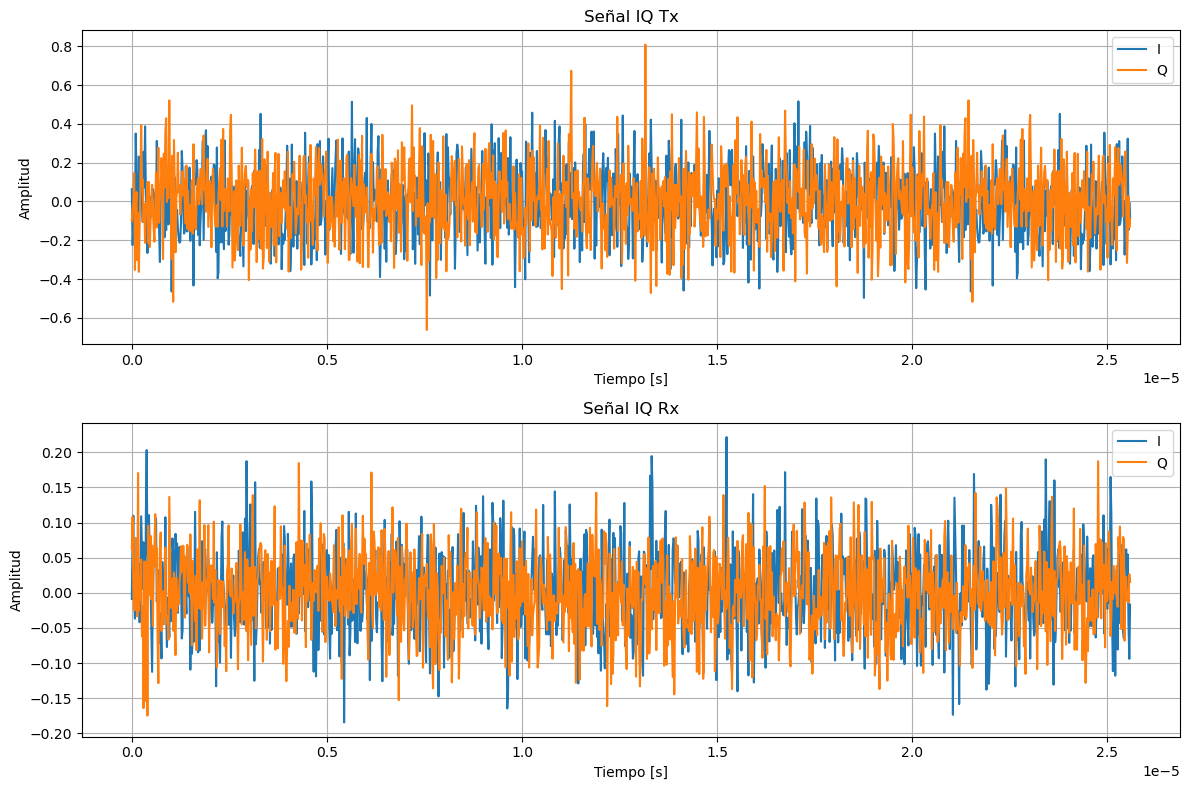

In [4]:
n_plot = 1280 # 3 símbolos a 1280 muestras/símbolo

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# ----------------------------
# TX
# ----------------------------
axes[0].plot(t_tx[:n_plot], np.real(iq_tx[:n_plot]), label="I")
axes[0].plot(t_tx[:n_plot], np.imag(iq_tx[:n_plot]), label="Q")
axes[0].set_title("Señal IQ Tx")
axes[0].set_xlabel("Tiempo [s]")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True)
axes[0].legend()

# ----------------------------
# RX
# ----------------------------
axes[1].plot(t_rx[:n_plot], np.real(iq_rx[:n_plot]), label="I")
axes[1].plot(t_rx[:n_plot], np.imag(iq_rx[:n_plot]), label="Q")
axes[1].set_title("Señal IQ Rx")
axes[1].set_xlabel("Tiempo [s]")
axes[1].set_ylabel("Amplitud")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
score_tx = _cp_tail_correlation_score(
    iq_tx,
    fft_size=1024,
    cp_len=256
)

score_rx = _cp_tail_correlation_score(
    iq_rx,
    fft_size=1024,
    cp_len=256
)

print(f"Tail Correlation Score (TX): {score_tx:.4f}")
print(f"Tail Correlation Score (RX): {score_rx:.4f}")

Tail Correlation Score (TX): 1.0000
Tail Correlation Score (RX): 0.5962


# 2) Demodulación

In [6]:
X, t_sym_tx, f_sub_tx = demodulate_ofdm_iq(
    iq_tx,
    yaml_path,
    n_symbols=None,
    fftshift=False,
    normalize_fft=False,
    return_axes=True,
    verbose=True,
)

Y, t_sym_rx, f_sub_rx = demodulate_ofdm_iq(
    iq_rx,
    yaml_path,
    n_symbols=None,
    fftshift=False,
    normalize_fft=False,
    return_axes=True,
    verbose=True,
)

print("Shape X:", X.shape)
print("Shape Y:", Y.shape)

assert X.shape == Y.shape, "X e Y deben tener la misma shape."

# print("Primeros símbolos:", t_sym_tx[:5])
# print("Primeras subportadoras [Hz]:", f_sub[:5])

Demodulación OFDM completada
  FFT size: 1024
  CP length: 256
  Símbolos demodulados: 100
  Shape rejilla OFDM: (100, 1024)
  fftshift: False
  normalize_fft: False
Demodulación OFDM completada
  FFT size: 1024
  CP length: 256
  Símbolos demodulados: 100
  Shape rejilla OFDM: (100, 1024)
  fftshift: False
  normalize_fft: False
Shape X: (100, 1024)
Shape Y: (100, 1024)


(<Figure size 1400x900 with 4 Axes>,
 array([<Axes: title={'center': 'X[m,k] - Módulo'}, ylabel='Tiempo [ms]'>,
        <Axes: title={'center': 'X[m,k] - Fase'}, xlabel='Frecuencia de subportadora [MHz]', ylabel='Tiempo [ms]'>],
       dtype=object))

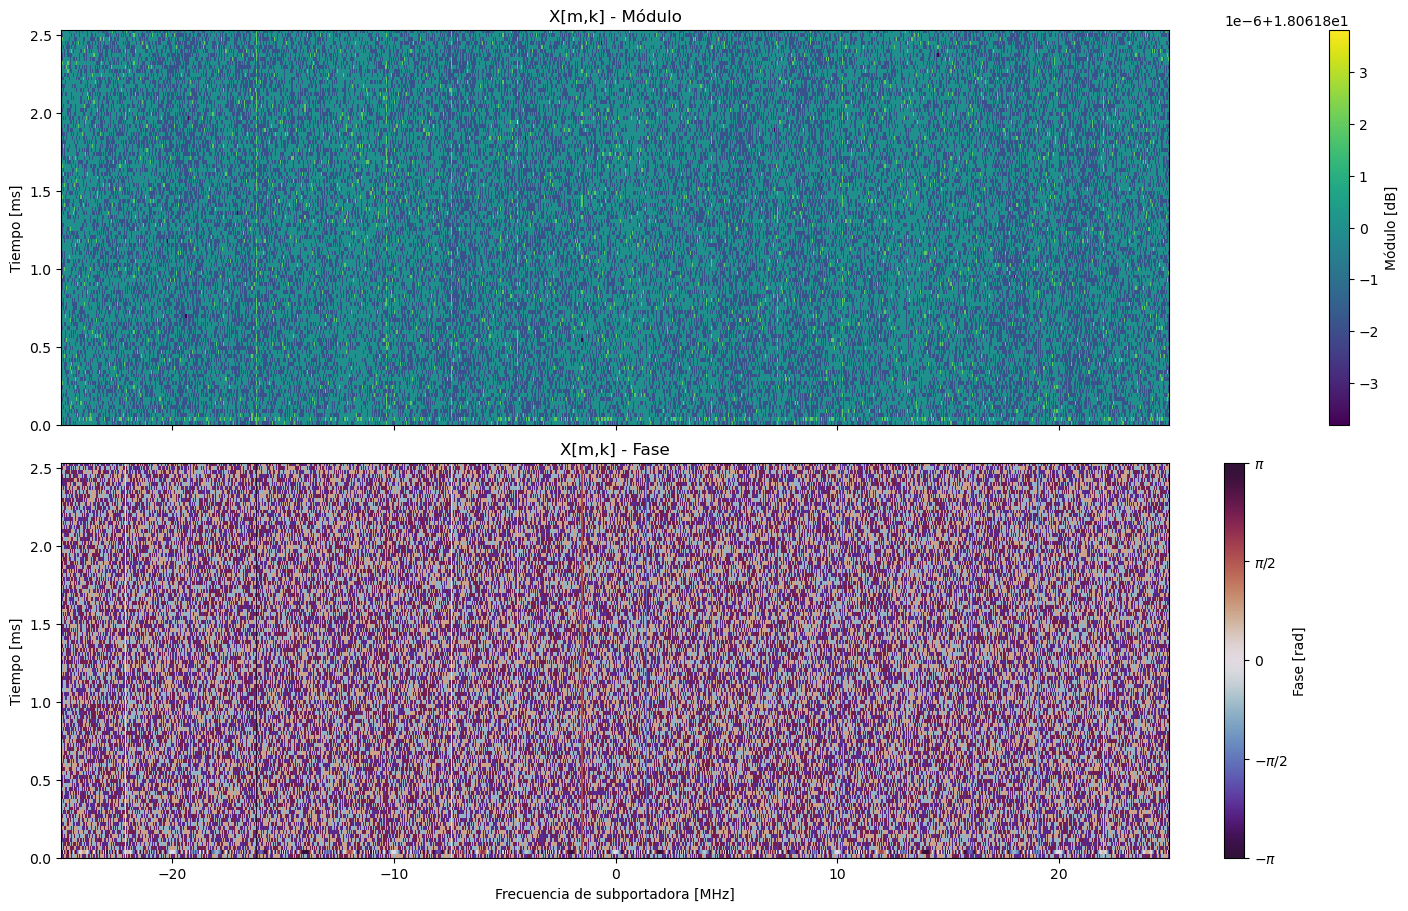

In [7]:
plot_ofdm_grid(
    X,
    t_sym_tx,
    f_sub_tx,
    title="X[m,k]",
    magnitude_db=True,
    freq_unit="MHz",
    time_unit="ms",
    fftshift_already_applied=False,
)

(<Figure size 1400x900 with 4 Axes>,
 array([<Axes: title={'center': 'Y[m,k] - Módulo'}, ylabel='Tiempo [ms]'>,
        <Axes: title={'center': 'Y[m,k] - Fase'}, xlabel='Frecuencia de subportadora [MHz]', ylabel='Tiempo [ms]'>],
       dtype=object))

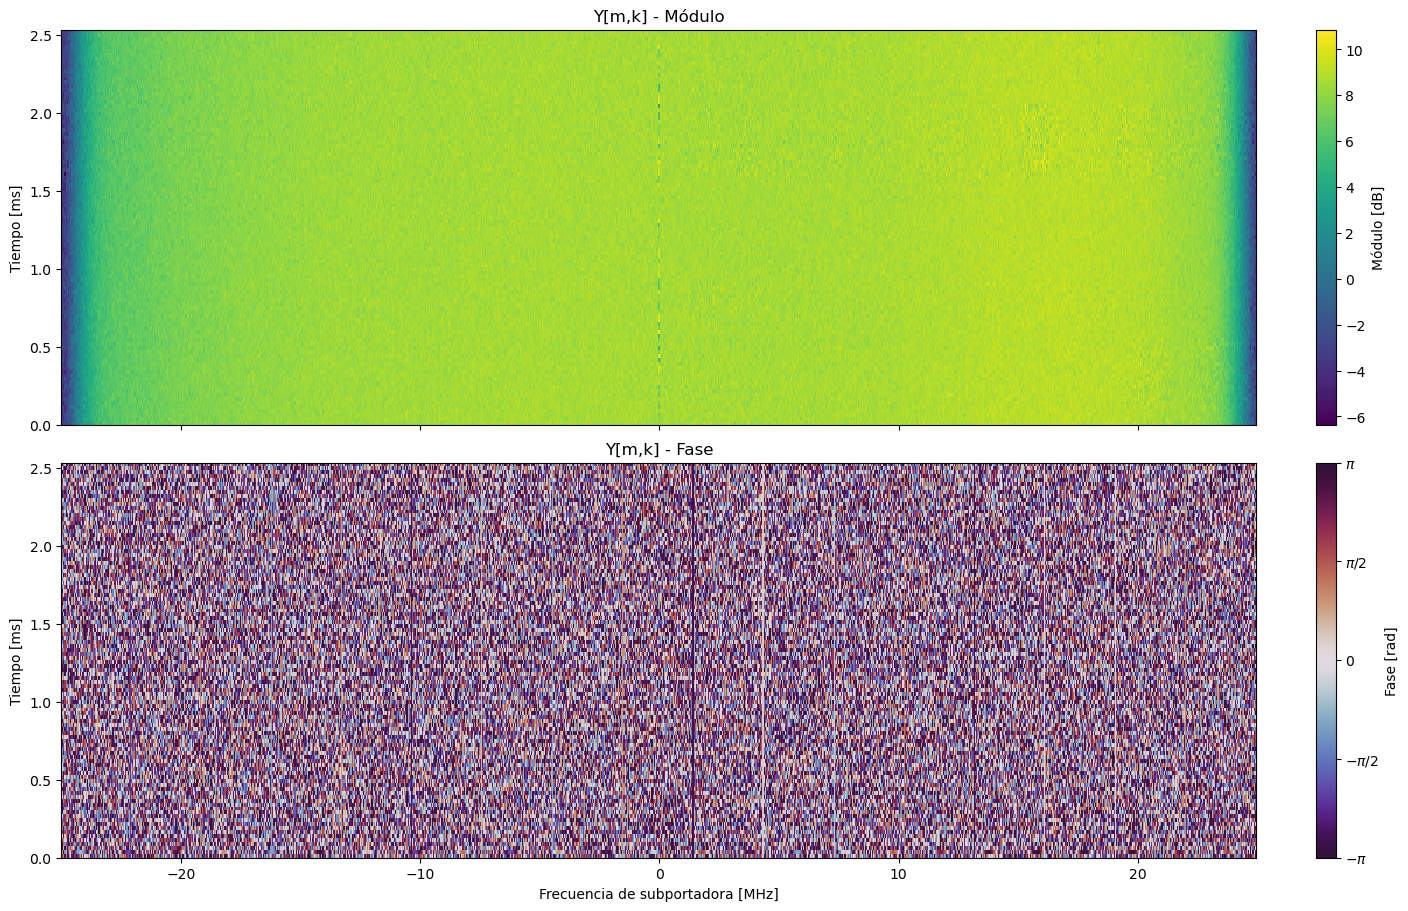

In [8]:
plot_ofdm_grid(
    Y,
    t_sym_rx,
    f_sub_rx,
    title="Y[m,k]",
    magnitude_db=True,
    freq_unit="MHz",
    time_unit="ms",
    fftshift_already_applied=False,
)

# 3) Estimación del canal

In [9]:
H, H_valid_mask = estimate_channel_grid(
    X,
    Y,
    eps=1e-12,
    return_mask=True,
    verbose=True,
)

Estimación de canal completada
  Shape H: (100, 1024)
  Posiciones válidas: 102400/102400


(<Figure size 1400x900 with 4 Axes>,
 array([<Axes: title={'center': 'H[m,k] - Módulo'}, ylabel='Tiempo [ms]'>,
        <Axes: title={'center': 'H[m,k] - Fase'}, xlabel='Frecuencia de subportadora [MHz]', ylabel='Tiempo [ms]'>],
       dtype=object))

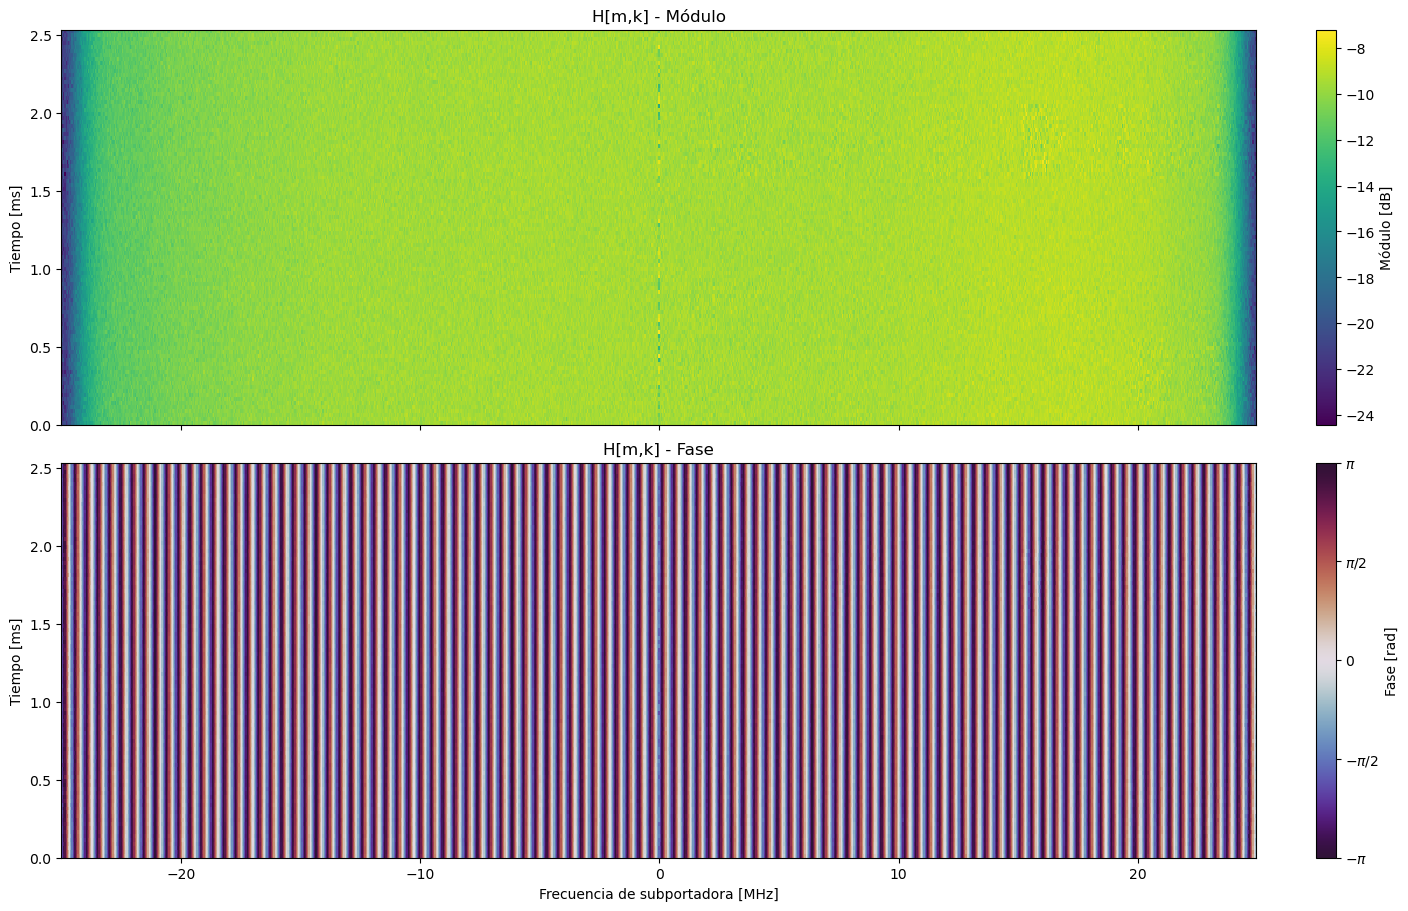

In [10]:
plot_ofdm_grid(
    H,
    t_sym_rx,
    f_sub_rx,
    title="H[m,k]",
    magnitude_db=True,
    freq_unit="MHz",
    time_unit="ms",
    fftshift_already_applied=False,
)

# 4) Conversión a retardos

In [11]:
cfg = load_modulator_yaml("Modulator.yaml")

h_tau_m, range_axis = delay_time_ifft_from_H(
    H,
    modulator_cfg=cfg,
)

# 5) Mapa rango-Doppler

In [12]:
RD, range_axis, doppler_axis = range_doppler_from_delay_time(
    h_tau_m,
    modulator_cfg=cfg,
    doppler_fft_size=cfg.get("doppler_fft_size"),
    window_slowtime="hann",
    to_db=True,
)

# 6) Espectrograma micro-Doppler

Delay bin con mayor energía: 104


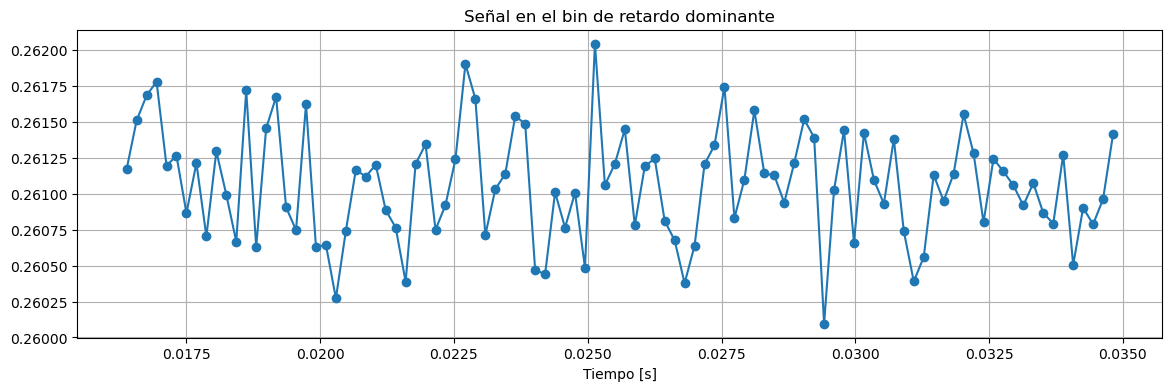

In [13]:
Smd, f_md, t_md, delay_bin, selected_range_m, slow_signal = microdoppler_from_delay_time(
    h_tau_m,
    modulator_cfg=cfg,
    nperseg=64,
    noverlap=63,
    nfft=128,
    window="hann",
    to_db=True,
)

print(f"Delay bin con mayor energía: {delay_bin}")

plt.figure(figsize=(14,4))
if len(slow_signal) == len(t_md):
    plt.plot(t_md, np.abs(slow_signal), '--')
else:
    time_axis = np.linspace(t_md[0], t_md[-1], len(slow_signal))
    plt.plot(time_axis, np.abs(slow_signal), '-o')
plt.xlabel("Tiempo [s]")
plt.title("Señal en el bin de retardo dominante")
plt.grid(True)
plt.show()

# 7) Output

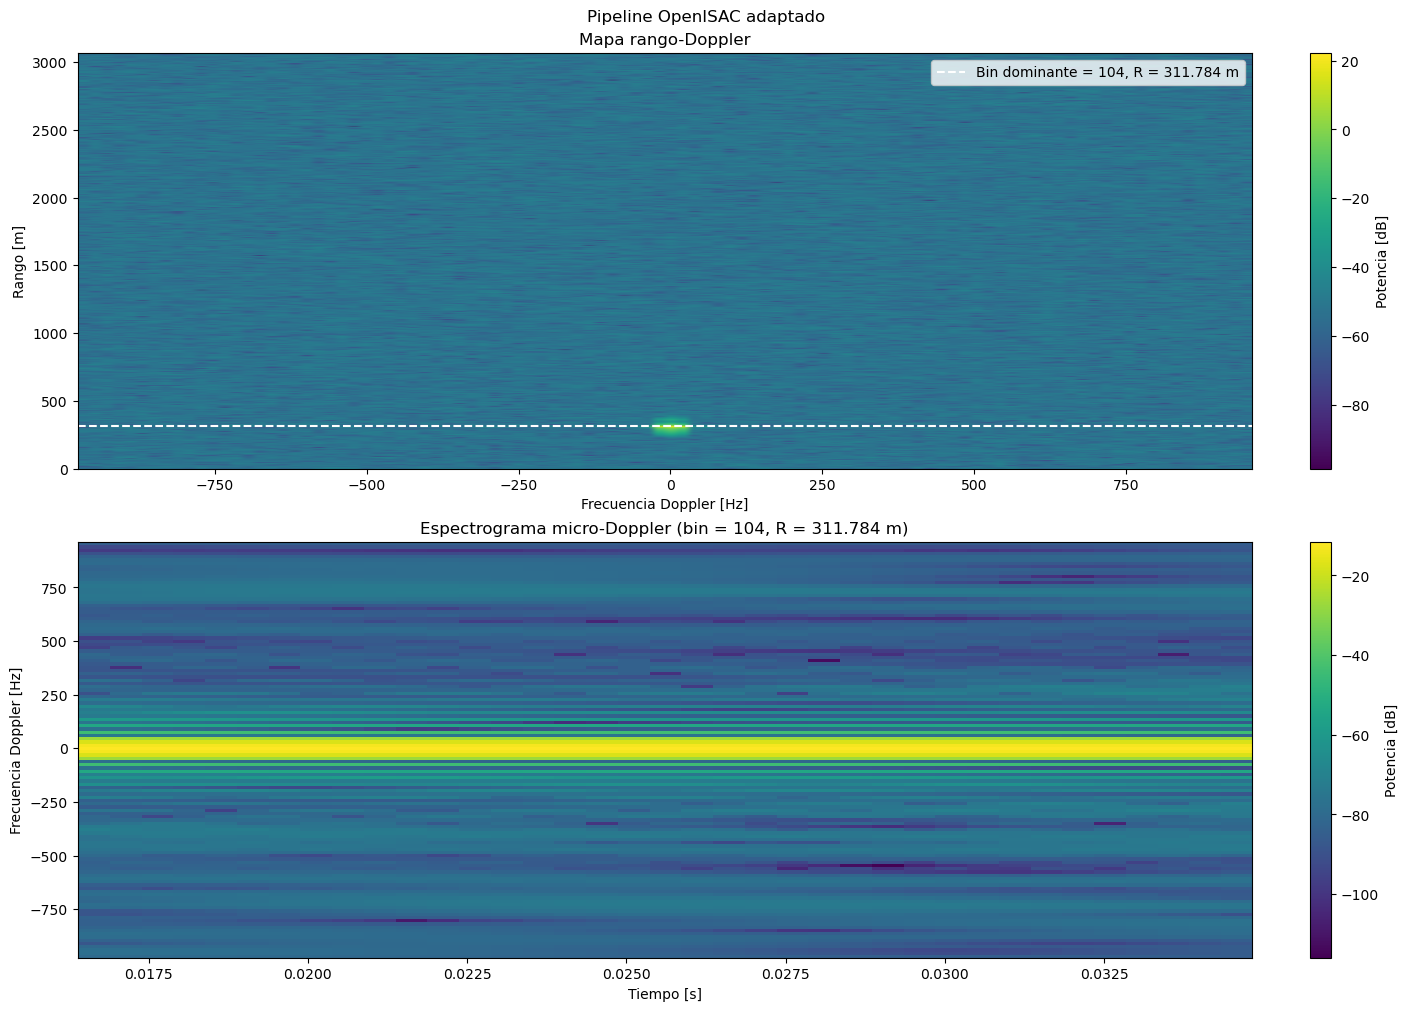

In [14]:
fig, axes = plot_rd_and_microdoppler(
    RD,
    range_axis,
    doppler_axis,
    Smd,
    f_md,
    t_md,
    delay_bin=delay_bin,
    rd_in_db=True,
    microdoppler_in_db=True,
    range_limits=None,
    doppler_limits=None,
    md_doppler_limits=None,
    title="Pipeline OpenISAC adaptado",
)

# Más ejemplos

(<Figure size 1400x1000 with 4 Axes>,
 array([<Axes: title={'center': 'Mapa rango-Doppler'}, xlabel='Frecuencia Doppler [Hz]', ylabel='Rango [m]'>,
        <Axes: title={'center': 'Espectrograma micro-Doppler (bin = 104, R = 311.784 m)'}, xlabel='Tiempo [s]', ylabel='Frecuencia Doppler [Hz]'>],
       dtype=object))

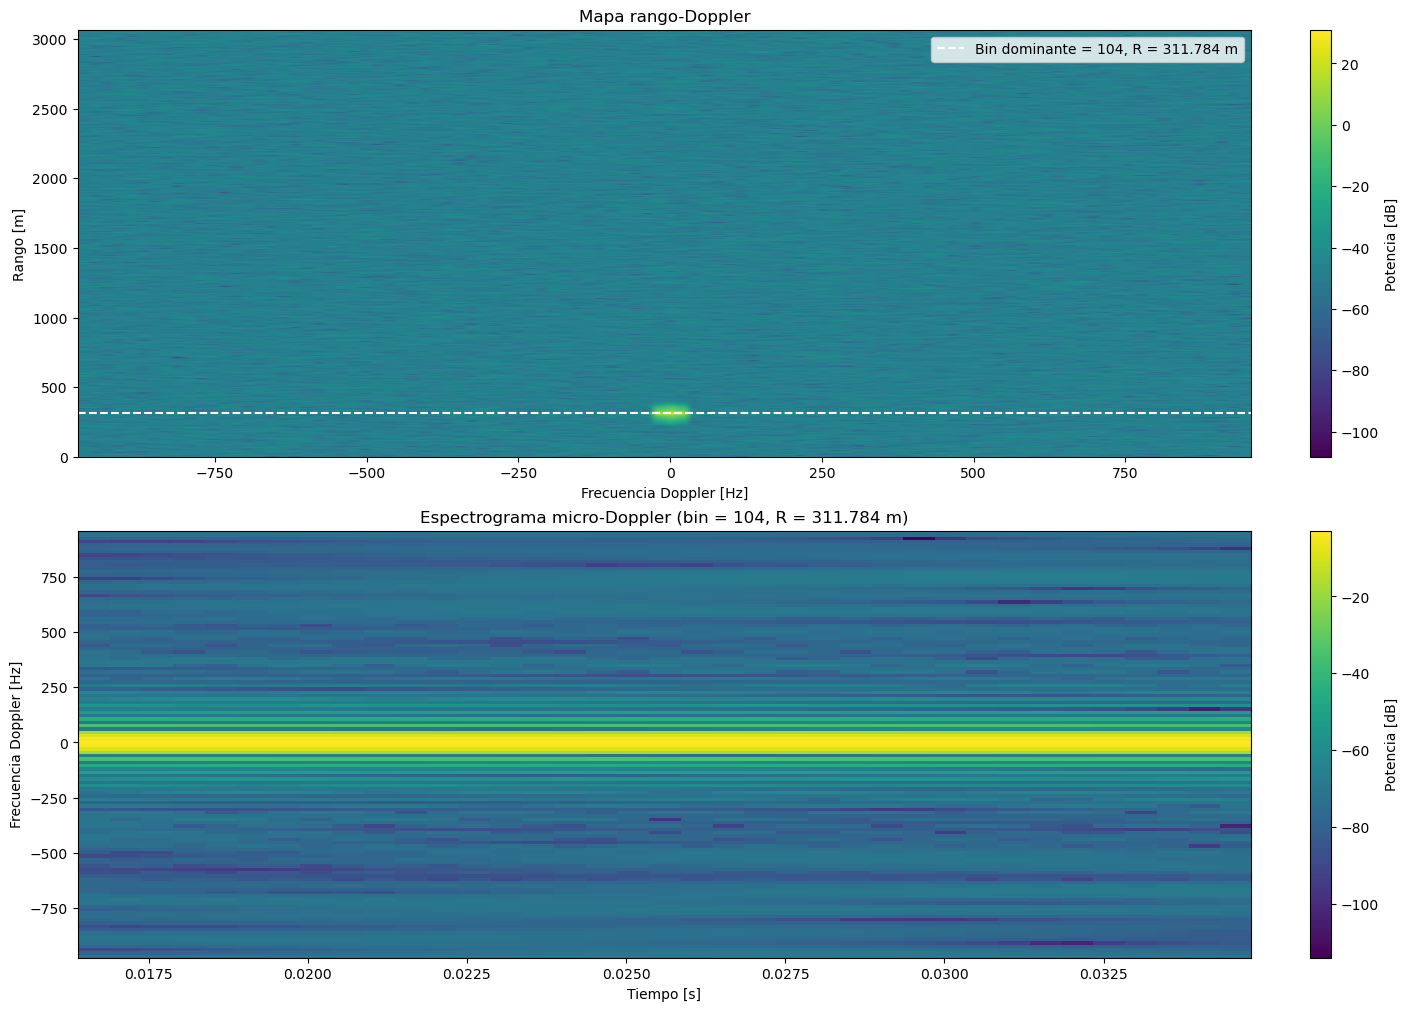

In [17]:
tx_path = repo_root / "data" / "carton" / "caliente" / "iq_tx_1.bin"
rx_path = repo_root / "data" / "carton" / "caliente" / "iq_rx_1.bin"

out = openisac_maps_from_iq_bins(
    tx_bin_path=tx_path,
    rx_bin_path=rx_path,
    yaml_path=yaml_path,
    min_range_m=None, #0.5,
    max_range_m=None, #20,
    md_nperseg=64,
    md_noverlap=63,
    md_nfft=128,
    verbose=False,
)

plot_rd_and_microdoppler(
    out["RD"],
    out["range_axis"],
    out["doppler_axis"],
    out["Smd"],
    out["f_md"],
    out["t_md"],
    delay_bin=out["delay_bin"],
    selected_range_m=out["selected_range_m"],
    range_limits= None, #(0, 20),
    doppler_limits= None, #(-500, 500),
    md_doppler_limits= None, #(-300, 300),
)

(<Figure size 1400x1000 with 4 Axes>,
 array([<Axes: title={'center': 'Mapa rango-Doppler'}, xlabel='Frecuencia Doppler [Hz]', ylabel='Rango [m]'>,
        <Axes: title={'center': 'Espectrograma micro-Doppler (bin = 103, R = 308.786 m)'}, xlabel='Tiempo [s]', ylabel='Frecuencia Doppler [Hz]'>],
       dtype=object))

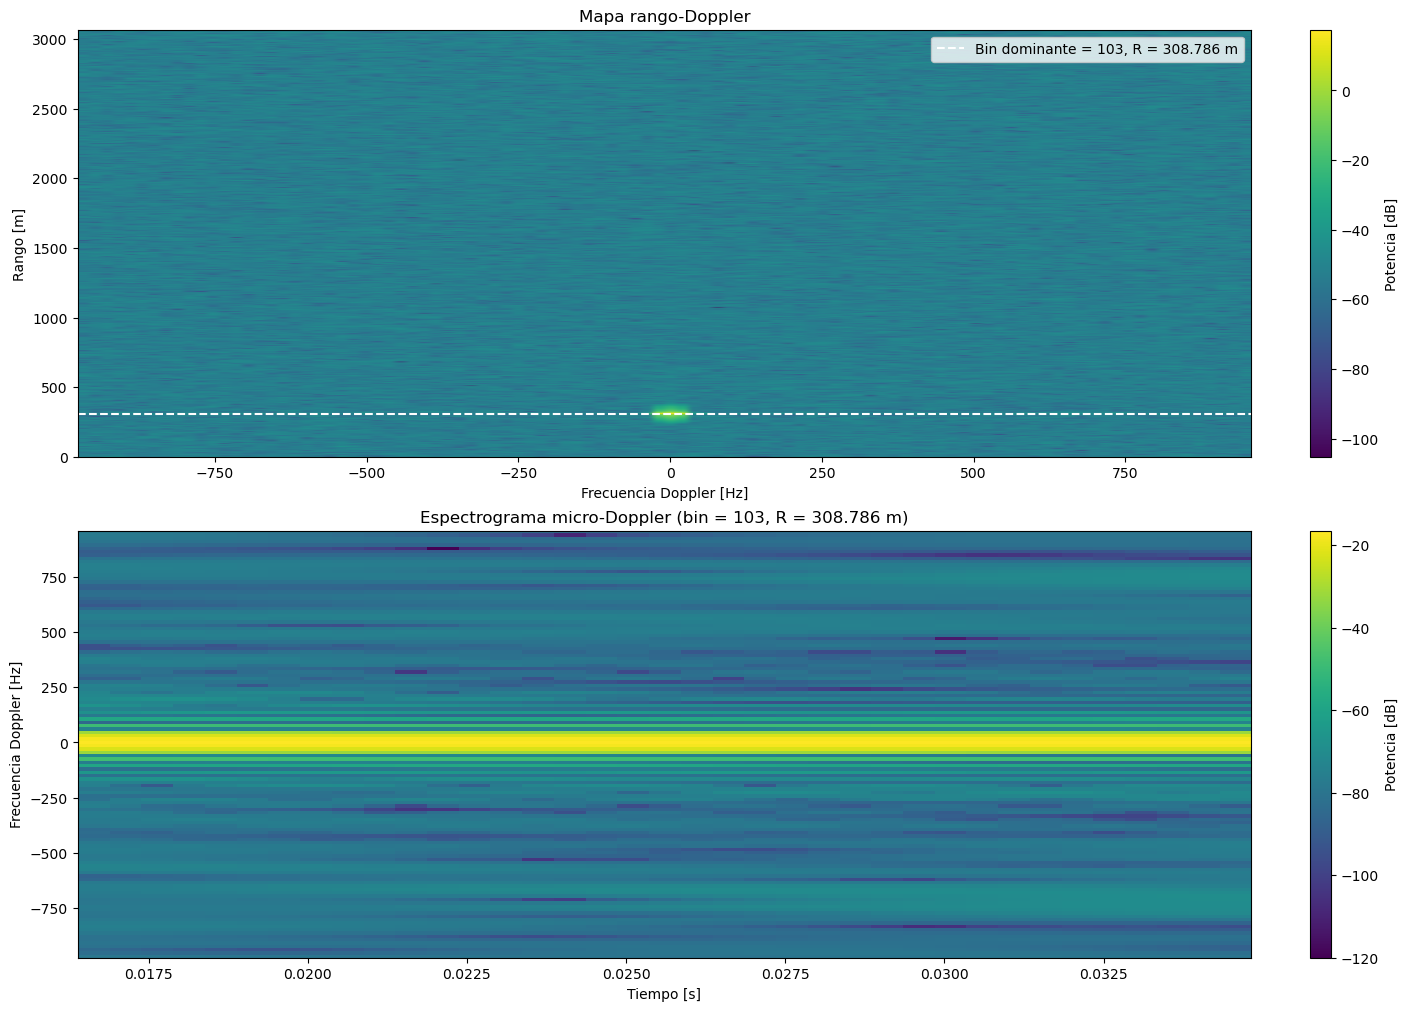

In [18]:
tx_path = repo_root / "data" / "carton" / "frio" / "iq_tx_1.bin"
rx_path = repo_root / "data" / "carton" / "frio" / "iq_rx_1.bin"

out = openisac_maps_from_iq_bins(
    tx_bin_path=tx_path,
    rx_bin_path=rx_path,
    yaml_path=yaml_path,
    min_range_m=None, #0.5,
    max_range_m=None, #20,
    md_nperseg=64,
    md_noverlap=63,
    md_nfft=128,
    verbose=False,
)

plot_rd_and_microdoppler(
    out["RD"],
    out["range_axis"],
    out["doppler_axis"],
    out["Smd"],
    out["f_md"],
    out["t_md"],
    delay_bin=out["delay_bin"],
    selected_range_m=out["selected_range_m"],
    range_limits= None, #(0, 20),
    doppler_limits= None, #(-500, 500),
    md_doppler_limits= None, #(-300, 300),
)

(<Figure size 1400x1000 with 4 Axes>,
 array([<Axes: title={'center': 'Mapa rango-Doppler'}, xlabel='Frecuencia Doppler [Hz]', ylabel='Rango [m]'>,
        <Axes: title={'center': 'Espectrograma micro-Doppler (bin = 104, R = 311.784 m)'}, xlabel='Tiempo [s]', ylabel='Frecuencia Doppler [Hz]'>],
       dtype=object))

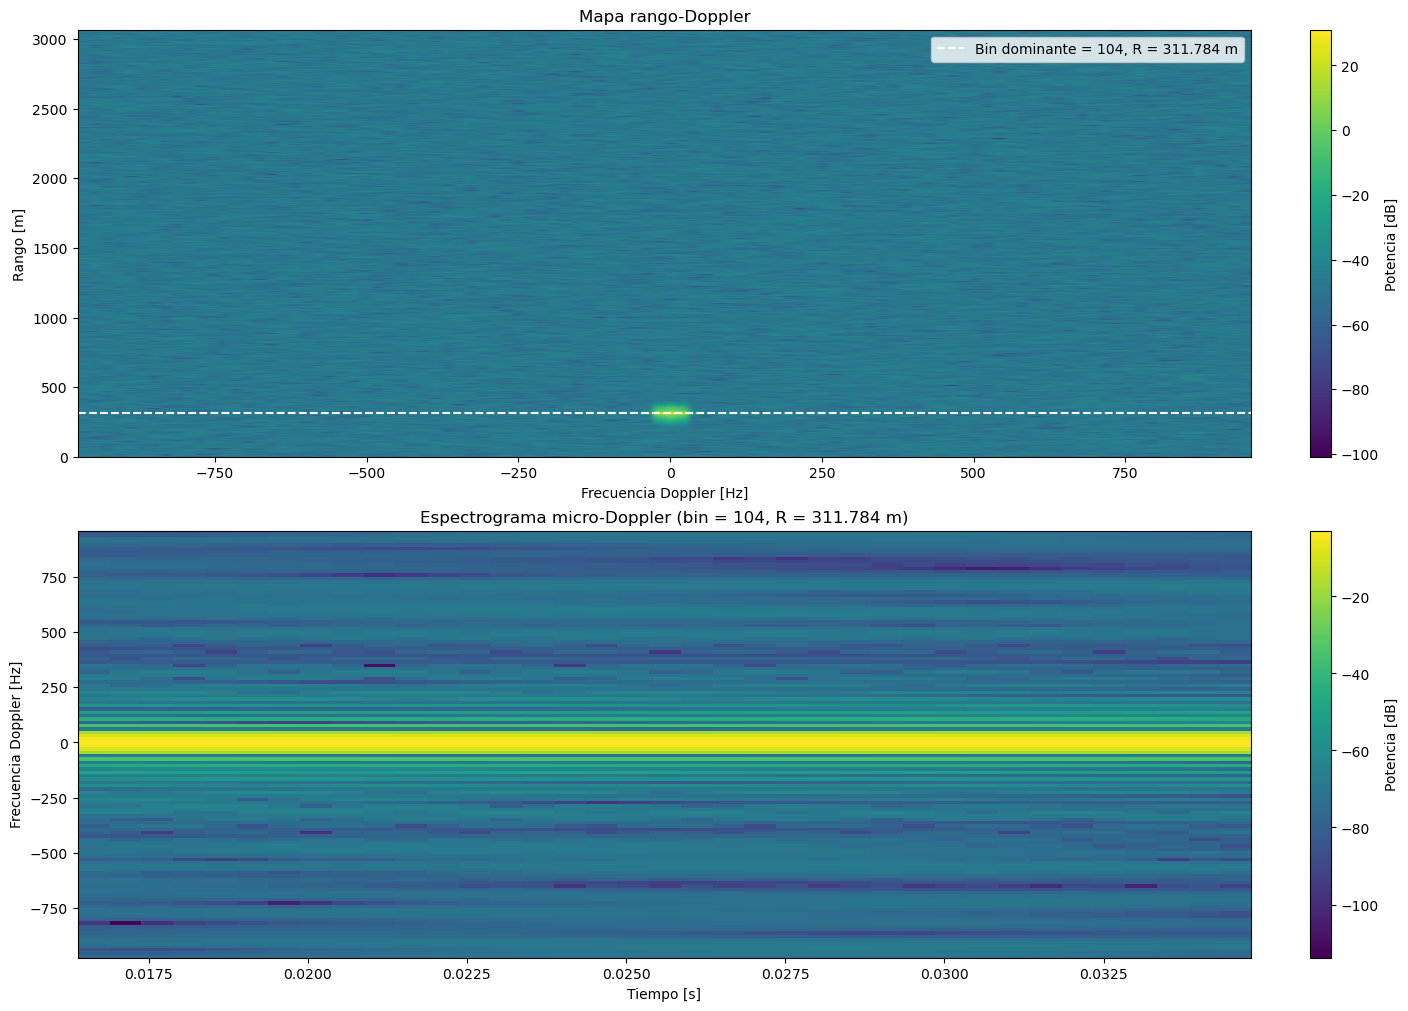

In [19]:
tx_path = repo_root / "data" / "carton" / "caliente" / "iq_tx_2.bin"
rx_path = repo_root / "data" / "carton" / "caliente" / "iq_rx_2.bin"

out = openisac_maps_from_iq_bins(
    tx_bin_path=tx_path,
    rx_bin_path=rx_path,
    yaml_path=yaml_path,
    min_range_m=None, #0.5,
    max_range_m=None, #20,
    md_nperseg=64,
    md_noverlap=63,
    md_nfft=128,
    verbose=False,
)

plot_rd_and_microdoppler(
    out["RD"],
    out["range_axis"],
    out["doppler_axis"],
    out["Smd"],
    out["f_md"],
    out["t_md"],
    delay_bin=out["delay_bin"],
    selected_range_m=out["selected_range_m"],
    range_limits= None, #(0, 20),
    doppler_limits= None, #(-500, 500),
    md_doppler_limits= None, #(-300, 300),
)

(<Figure size 1400x1000 with 4 Axes>,
 array([<Axes: title={'center': 'Mapa rango-Doppler'}, xlabel='Frecuencia Doppler [Hz]', ylabel='Rango [m]'>,
        <Axes: title={'center': 'Espectrograma micro-Doppler (bin = 103, R = 308.786 m)'}, xlabel='Tiempo [s]', ylabel='Frecuencia Doppler [Hz]'>],
       dtype=object))

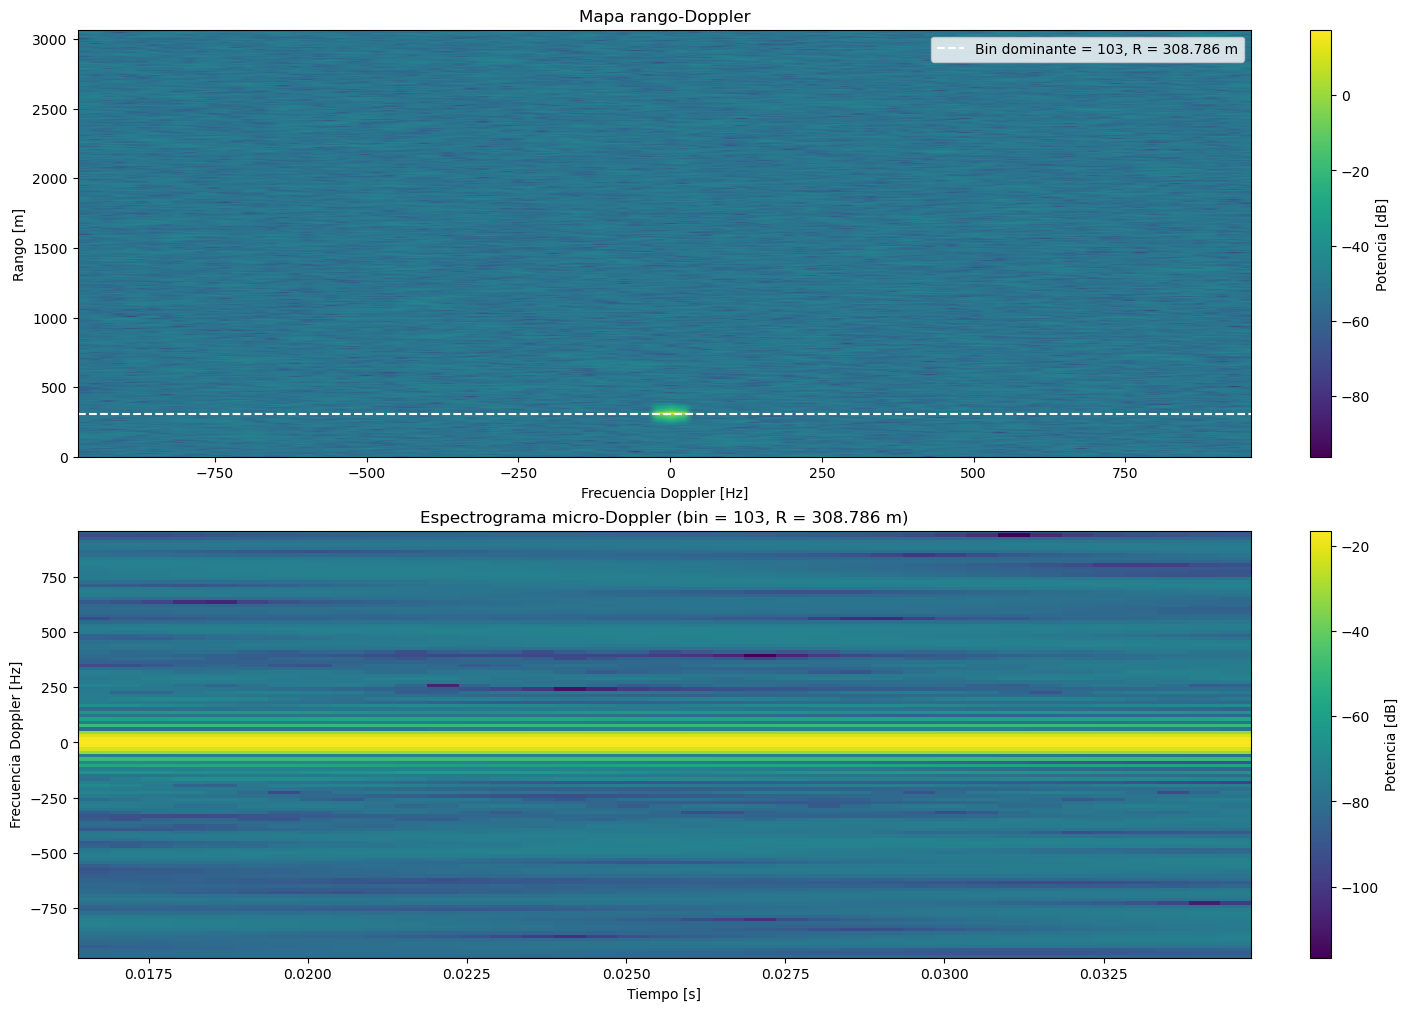

In [20]:
tx_path = repo_root / "data" / "carton" / "frio" / "iq_tx_2.bin"
rx_path = repo_root / "data" / "carton" / "frio" / "iq_rx_2.bin"

out = openisac_maps_from_iq_bins(
    tx_bin_path=tx_path,
    rx_bin_path=rx_path,
    yaml_path=yaml_path,
    min_range_m=None, #0.5,
    max_range_m=None, #20,
    md_nperseg=64,
    md_noverlap=63,
    md_nfft=128,
    verbose=False,
)

plot_rd_and_microdoppler(
    out["RD"],
    out["range_axis"],
    out["doppler_axis"],
    out["Smd"],
    out["f_md"],
    out["t_md"],
    delay_bin=out["delay_bin"],
    selected_range_m=out["selected_range_m"],
    range_limits= None, #(0, 20),
    doppler_limits= None, #(-500, 500),
    md_doppler_limits= None, #(-300, 300),
)

(<Figure size 1400x1000 with 4 Axes>,
 array([<Axes: title={'center': 'Mapa rango-Doppler'}, xlabel='Frecuencia Doppler [Hz]', ylabel='Rango [m]'>,
        <Axes: title={'center': 'Espectrograma micro-Doppler (bin = 104, R = 311.784 m)'}, xlabel='Tiempo [s]', ylabel='Frecuencia Doppler [Hz]'>],
       dtype=object))

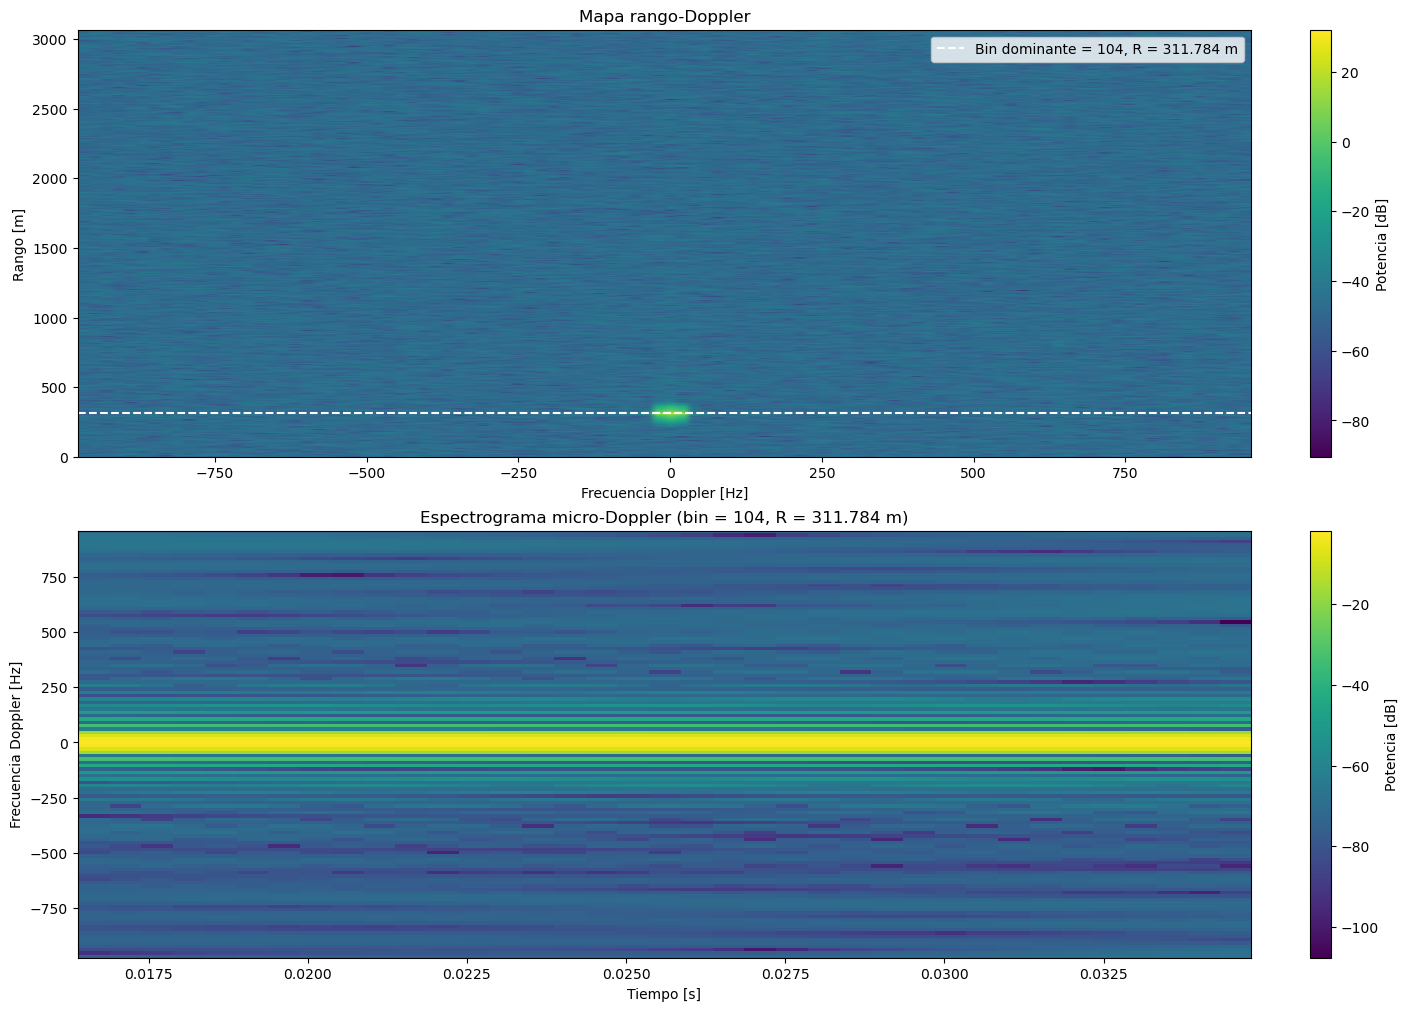

In [21]:
tx_path = repo_root / "data" / "cristal" / "caliente" / "iq_tx_1.bin"
rx_path = repo_root / "data" / "cristal" / "caliente" / "iq_rx_1.bin"

out = openisac_maps_from_iq_bins(
    tx_bin_path=tx_path,
    rx_bin_path=rx_path,
    yaml_path=yaml_path,
    min_range_m=None, #0.5,
    max_range_m=None, #20,
    md_nperseg=64,
    md_noverlap=63,
    md_nfft=128,
    verbose=False,
)

plot_rd_and_microdoppler(
    out["RD"],
    out["range_axis"],
    out["doppler_axis"],
    out["Smd"],
    out["f_md"],
    out["t_md"],
    delay_bin=out["delay_bin"],
    selected_range_m=out["selected_range_m"],
    range_limits= None, #(0, 20),
    doppler_limits= None, #(-500, 500),
    md_doppler_limits= None, #(-300, 300),
)

(<Figure size 1400x1000 with 4 Axes>,
 array([<Axes: title={'center': 'Mapa rango-Doppler'}, xlabel='Frecuencia Doppler [Hz]', ylabel='Rango [m]'>,
        <Axes: title={'center': 'Espectrograma micro-Doppler (bin = 103, R = 308.786 m)'}, xlabel='Tiempo [s]', ylabel='Frecuencia Doppler [Hz]'>],
       dtype=object))

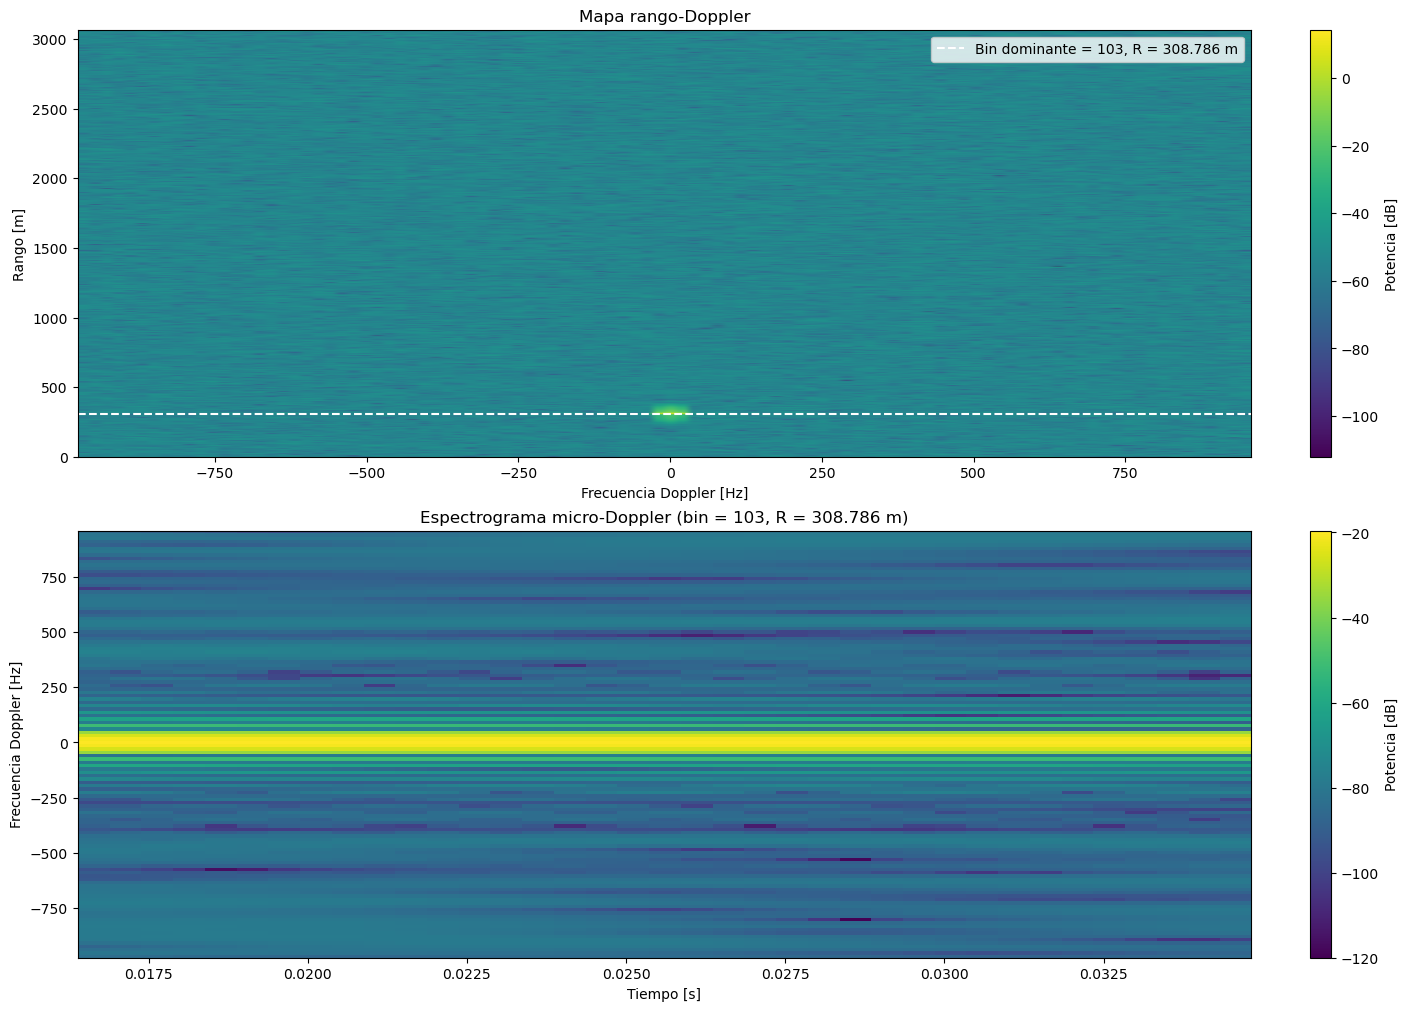

In [22]:
tx_path = repo_root / "data" / "cristal" / "frio" / "iq_tx_1.bin"
rx_path = repo_root / "data" / "cristal" / "frio" / "iq_rx_1.bin"

out = openisac_maps_from_iq_bins(
    tx_bin_path=tx_path,
    rx_bin_path=rx_path,
    yaml_path=yaml_path,
    min_range_m=None, #0.5,
    max_range_m=None, #20,
    md_nperseg=64,
    md_noverlap=63,
    md_nfft=128,
    verbose=False,
)

plot_rd_and_microdoppler(
    out["RD"],
    out["range_axis"],
    out["doppler_axis"],
    out["Smd"],
    out["f_md"],
    out["t_md"],
    delay_bin=out["delay_bin"],
    selected_range_m=out["selected_range_m"],
    range_limits= None, #(0, 20),
    doppler_limits= None, #(-500, 500),
    md_doppler_limits= None, #(-300, 300),
)